# Entrega 2 — Análise preliminar de furtos e roubos na Grande Vitória

**Disciplina:** Projeto Integrador III — Aplicações de Ciência de Dados  
**Tema:** Análise preliminar de furtos e roubos na Grande Vitória  
**Foco da Entrega 2:** análise exploratória, visualizações temporais e baseline inicial  
**Grupo:** Alexsander, Ester, Larissa Moraes, Lucas Rufino, Marcelo Mindas, Vanderson de Almeida  
**Data:** Maio de 2026

---

## Objetivo deste notebook

Este notebook organiza a Entrega 2 do projeto, com foco em construir um protótipo funcional de análise de dados. A análise parte dos microdados de ocorrências, aplica o recorte definido pelo grupo e gera visualizações preliminares para identificar padrões de furtos e roubos na Grande Vitória, especialmente em relação ao horário das ocorrências.

O notebook está organizado para responder às seguintes perguntas:

1. A base contém as colunas necessárias para o projeto?
2. Quantas ocorrências permanecem após aplicar o recorte de período, municípios e tipos de crime?
3. Como furtos e roubos se distribuem por município, mês, dia da semana e hora?
4. Existem diferenças visíveis entre o padrão horário de furtos e roubos?
5. Um baseline simples consegue servir como referência inicial para a próxima etapa de modelagem?


## Checklist da Entrega 2

- [x] Carregar os dados
- [x] Verificar colunas disponíveis
- [x] Filtrar furtos e roubos
- [x] Filtrar municípios da Grande Vitória
- [x] Tratar data e horário
- [x] Criar coluna de mês
- [x] Criar coluna de dia da semana
- [x] Criar coluna de hora
- [x] Gerar gráfico por tipo de crime
- [x] Gerar gráfico por município
- [x] Gerar gráfico por mês
- [x] Gerar gráfico por dia da semana
- [x] Gerar gráfico por hora
- [x] Criar baseline/modelo simples
- [x] Escrever principais insights preliminares

> Observação: os itens foram marcados como concluídos porque este notebook já contém as células correspondentes. Depois de rodar tudo, confira se não houve erro em nenhuma etapa.


## 1. Bibliotecas utilizadas


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


## 2. Configurações gerais do projeto


In [2]:

# Municípios que compõem o recorte da Grande Vitória usado no projeto.
municipios_gv = [
    "VITORIA",
    "VILA VELHA",
    "SERRA",
    "CARIACICA",
    "VIANA",
    "GUARAPARI",
    "FUNDAO",
]

# Recorte temporal definido para a análise preliminar.
# Se o grupo decidir trabalhar apenas com meses totalmente consolidados,
# uma alternativa conservadora é trocar dt_fim para "2026-03-31".
dt_inicio = pd.Timestamp("2021-03-01")
dt_fim = pd.Timestamp("2026-04-30")

# Ordem padronizada dos dias da semana para gráficos.
ordem_dias = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo",
]

traducao_dias = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo",
}


## 3. Carregamento dos dados


In [3]:

# Esta lista deixa o notebook flexível para rodar em locais diferentes:
# - dentro de uma pasta notebooks/ do repositório;
# - na raiz do projeto;
# - no ambiente temporário usado para esta organização.
caminhos_possiveis = [
    Path("../dados/brutos/MICRODADOS_OCORRENCIAS.xlsx"),
    Path("../dados/brutos/MICRODADOS_OCORRENCIAS.csv"),
    Path("dados/brutos/MICRODADOS_OCORRENCIAS.xlsx"),
    Path("dados/brutos/MICRODADOS_OCORRENCIAS.csv"),
    Path("MICRODADOS_OCORRENCIAS.xlsx"),
    Path("MICRODADOS_OCORRENCIAS.csv"),
    Path("/mnt/data/MICRODADOS_OCORRENCIAS.csv"),
]


def carregar_microdados(caminhos):
    # Carrega os microdados em CSV ou XLSX, testando caminhos comuns do projeto.
    for caminho in caminhos:
        if not caminho.exists():
            continue

        print(f"Arquivo encontrado: {caminho}")

        if caminho.suffix.lower() in [".xlsx", ".xls"]:
            return pd.read_excel(caminho)

        if caminho.suffix.lower() == ".csv":
            # A base enviada está em CSV com separador ';' e codificação compatível com latin1/cp1252.
            for encoding in ["utf-8", "latin1", "cp1252"]:
                try:
                    df = pd.read_csv(caminho, sep=";", encoding=encoding)
                    if df.shape[1] > 1:
                        print(f"CSV carregado com encoding='{encoding}' e separador=';'.")
                        return df
                except UnicodeDecodeError:
                    continue
                except Exception as erro:
                    print(f"Tentativa falhou com encoding={encoding}: {erro}")

    raise FileNotFoundError(
        "Arquivo de microdados não encontrado. Verifique se o arquivo está em dados/brutos/ "
        "ou ajuste a lista caminhos_possiveis."
    )


dados = carregar_microdados(caminhos_possiveis)
print("Base carregada com sucesso!")


Arquivo encontrado: MICRODADOS_OCORRENCIAS.csv
CSV carregado com encoding='latin1' e separador=';'.
Base carregada com sucesso!


## 4. Visualização inicial da base


In [4]:

print("Dimensão da base original:")
print(f"Linhas: {dados.shape[0]:,}".replace(",", "."))
print(f"Colunas: {dados.shape[1]}")

print("\nColunas disponíveis:")
display(pd.DataFrame({"coluna": dados.columns}))

print("\nAmostra da base original:")
display(dados.sample(10, random_state=42))


Dimensão da base original:
Linhas: 617.940
Colunas: 6

Colunas disponíveis:


,coluna
0,Data
1,Hora
2,TipoIncidente
3,TipoLocal
4,Municipio
5,Bairro



Amostra da base original:


,Data,Hora,TipoIncidente,TipoLocal,Municipio,Bairro
305481,16/06/2022,18:52:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VILA VELHA,DIVINO ESPIRITO SANTO
410545,08/02/2021,15:12:00,ROUBO: EM ESTABELECIMENTO COMERCIAL,COMÉRCIO,SERRA,PARQUE RESIDENCIAL LARANJEIRAS
383403,06/07/2021,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,VITORIA,JUCUTUQUARA
313304,13/05/2022,22:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
185279,12/12/2023,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,GUARAPARI,OUTRO LOCAL
296597,27/07/2022,00:00:00,ESTELIONATO/FRAUDE,NaN,SERRA,JARDIM LIMOEIRO
190848,17/11/2023,15:30:00,ESTELIONATO/FRAUDE,AMBIENTE WEB,MIMOSO DO SUL,SANTA ROSA
288033,03/09/2022,18:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
361819,21/10/2021,17:30:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
486620,17/11/2019,16:40:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VIANA,CANAA


In [5]:

print("Informações gerais da base:")
dados.info()


Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 617940 entries, 0 to 617939
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Data           617940 non-null  str  
 1   Hora           617940 non-null  str  
 2   TipoIncidente  617940 non-null  str  
 3   TipoLocal      535736 non-null  str  
 4   Municipio      617940 non-null  str  
 5   Bairro         617940 non-null  str  
dtypes: str(6)
memory usage: 28.3 MB


In [6]:

print("Quantidade de valores ausentes por coluna:")
display(dados.isna().sum().sort_values(ascending=False).to_frame("qtd_ausentes"))


Quantidade de valores ausentes por coluna:


,qtd_ausentes
TipoLocal,82204
Data,0
Hora,0
TipoIncidente,0
Municipio,0
Bairro,0


### Conferência das colunas essenciais

Para a Entrega 2, a base precisa ter pelo menos:

- `Data`
- `Hora`
- `TipoIncidente`
- `Municipio`

A coluna `Bairro` também é útil, mas nesta entrega o foco principal será município e tempo.


In [7]:

colunas_necessarias = ["Data", "Hora", "TipoIncidente", "Municipio"]
colunas_faltantes = [col for col in colunas_necessarias if col not in dados.columns]

if colunas_faltantes:
    raise ValueError(f"Colunas necessárias ausentes: {colunas_faltantes}")
else:
    print("Todas as colunas essenciais foram encontradas.")


Todas as colunas essenciais foram encontradas.


## 5. Tratamento inicial dos dados


In [8]:

# Cópia de trabalho para preservar a base original carregada.
dados_trat = dados.copy()

# Padronização de textos: remove espaços extras e coloca em letras maiúsculas.
colunas_texto = ["TipoIncidente", "TipoLocal", "Municipio", "Bairro"]

for coluna in colunas_texto:
    if coluna in dados_trat.columns:
        dados_trat[coluna] = (
            dados_trat[coluna]
            .astype("string")
            .str.strip()
            .str.upper()
        )

print("Padronização textual concluída.")


Padronização textual concluída.


In [9]:

# Conversão da data.
# dayfirst=True é importante porque a base usa formato brasileiro: dia/mês/ano.
dados_trat["DataOriginal"] = dados_trat["Data"]
dados_trat["Data"] = pd.to_datetime(dados_trat["Data"], errors="coerce", dayfirst=True)

print("Datas inválidas após conversão:", dados_trat["Data"].isna().sum())
print("Período original identificado:")
print(dados_trat["Data"].min(), "até", dados_trat["Data"].max())


Datas inválidas após conversão: 0
Período original identificado:
2018-01-01 00:00:00 até 2026-04-30 00:00:00


## 6. Filtragem do escopo do projeto

O recorte da Entrega 2 segue três filtros principais:

1. **Período:** aproximadamente últimos 5 anos disponíveis na base;
2. **Municípios:** Grande Vitória;
3. **Tipo de crime:** furtos e roubos.

> Ponto corrigido em relação ao rascunho anterior: o filtro dos municípios deve ser feito na coluna `Municipio`, não na coluna `TipoIncidente`.


In [10]:

# 1) Filtro de período
dados_periodo = dados_trat[
    (dados_trat["Data"] >= dt_inicio) &
    (dados_trat["Data"] <= dt_fim)
].copy()

# 2) Filtro de municípios da Grande Vitória
dados_gv = dados_periodo[
    dados_periodo["Municipio"].isin(municipios_gv)
].copy()

# 3) Filtro de furtos e roubos
dados_filtr = dados_gv[
    dados_gv["TipoIncidente"].str.contains("FURTO|ROUBO", na=False)
].copy()

resumo_filtros = pd.DataFrame({
    "etapa": [
        "Base original",
        "Após filtro de período",
        "Após filtro de municípios da GV",
        "Após filtro de furtos e roubos",
    ],
    "linhas": [
        len(dados_trat),
        len(dados_periodo),
        len(dados_gv),
        len(dados_filtr),
    ]
})

resumo_filtros["perc_em_relacao_base_original"] = (
    resumo_filtros["linhas"] / len(dados_trat) * 100
).round(2)

display(resumo_filtros)

if dados_filtr.empty:
    raise ValueError(
        "A base filtrada ficou vazia. Confira os nomes dos municípios, o período e o filtro de TipoIncidente."
    )


,etapa,linhas,perc_em_relacao_base_original
0,Base original,617940,100.00
1,Após filtro de período,406806,65.83
2,Após filtro de municípios da GV,273454,44.25
3,Após filtro de furtos e roubos,120696,19.53


In [11]:

print("Municípios encontrados após o recorte:")
display(dados_filtr["Municipio"].value_counts().to_frame("ocorrencias"))

print("\nTipos de incidente mais frequentes no recorte:")
display(dados_filtr["TipoIncidente"].value_counts().head(20).to_frame("ocorrencias"))


Municípios encontrados após o recorte:


,ocorrencias
Municipio,
SERRA,33320
VILA VELHA,28833
VITORIA,26135
CARIACICA,24465
GUARAPARI,4987
VIANA,2229
FUNDAO,727



Tipos de incidente mais frequentes no recorte:


,ocorrencias
TipoIncidente,
ROUBO: A PESSOA EM VIA PÚBLICA,59092
FURTO: EM ESTABELECIMENTO COMERCIAL,15016
FURTO: EM RESIDÊNCIA/CONDOMÍNIO,12864
FURTO: A PESSOA EM VIA PÚBLICA,12568
FURTO: EM TRANSPORTE COLETIVO,9067
ROUBO: EM TRANSPORTE COLETIVO,8236
ROUBO: EM ESTABELECIMENTO COMERCIAL,3155
ROUBO: EM RESIDÊNCIA/CONDOMÍNIO,698


## 7. Criação de variáveis derivadas


In [12]:

# Categoria resumida: Furto ou Roubo.
def categorizar_crime(tipo):
    if pd.isna(tipo):
        return np.nan
    if "FURTO" in tipo:
        return "Furto"
    if "ROUBO" in tipo:
        return "Roubo"
    return "Outro"


dados_filtr["CategoriaCrime"] = dados_filtr["TipoIncidente"].apply(categorizar_crime)

print("Distribuição por categoria resumida:")
display(dados_filtr["CategoriaCrime"].value_counts().to_frame("ocorrencias"))


Distribuição por categoria resumida:


,ocorrencias
CategoriaCrime,
Roubo,71181
Furto,49515


In [13]:

# Variáveis temporais derivadas da data.
dados_filtr["Ano"] = dados_filtr["Data"].dt.year
dados_filtr["Mes"] = dados_filtr["Data"].dt.month
dados_filtr["NomeMes"] = dados_filtr["Data"].dt.month_name(locale=None)
dados_filtr["AnoMes"] = dados_filtr["Data"].dt.to_period("M")
dados_filtr["DiaSemana"] = dados_filtr["Data"].dt.day_name().map(traducao_dias)

# Garante ordenação correta nos gráficos.
dados_filtr["DiaSemana"] = pd.Categorical(
    dados_filtr["DiaSemana"],
    categories=ordem_dias,
    ordered=True
)

print("Variáveis de data criadas: Ano, Mes, NomeMes, AnoMes e DiaSemana.")
display(dados_filtr[["Data", "Ano", "Mes", "AnoMes", "DiaSemana"]].head())


Variáveis de data criadas: Ano, Mes, NomeMes, AnoMes e DiaSemana.


,Data,Ano,Mes,AnoMes,DiaSemana
23,2026-04-30,2026,4,2026-04,Quinta-feira
33,2026-04-30,2026,4,2026-04,Quinta-feira
37,2026-04-30,2026,4,2026-04,Quinta-feira
39,2026-04-30,2026,4,2026-04,Quinta-feira
45,2026-04-30,2026,4,2026-04,Quinta-feira


In [14]:

# Tratamento da hora.
# Horários como 'Indeterminada' serão convertidos para NaT.
dados_filtr["HoraOriginal"] = dados_filtr["Hora"]
dados_filtr["HoraConvertida"] = pd.to_datetime(
    dados_filtr["Hora"].astype("string").str.strip(),
    format="%H:%M:%S",
    errors="coerce"
)

dados_filtr["HoraDia"] = dados_filtr["HoraConvertida"].dt.hour.astype("Int64")

# Faixas horárias para facilitar interpretação.
dados_filtr["FaixaHorario"] = pd.cut(
    dados_filtr["HoraDia"].astype("float"),
    bins=[0, 6, 12, 18, 24],
    labels=[
        "Madrugada (00h-05h)",
        "Manhã (06h-11h)",
        "Tarde (12h-17h)",
        "Noite (18h-23h)",
    ],
    right=False,
)

qtd_hora_invalida = dados_filtr["HoraDia"].isna().sum()
perc_hora_invalida = qtd_hora_invalida / len(dados_filtr) * 100

print(f"Registros no recorte: {len(dados_filtr):,}".replace(",", "."))
print(f"Registros sem hora válida: {qtd_hora_invalida:,} ({perc_hora_invalida:.2f}%)".replace(",", "."))

# Base auxiliar para gráficos por hora.
dados_hora = dados_filtr.dropna(subset=["HoraDia"]).copy()
dados_hora["HoraDia"] = dados_hora["HoraDia"].astype(int)

print(f"Registros usados nas análises por hora: {len(dados_hora):,}".replace(",", "."))


Registros no recorte: 120.696
Registros sem hora válida: 7.015 (5.81%)
Registros usados nas análises por hora: 113.681


### Decisão metodológica sobre horários indeterminados

Registros sem horário válido foram mantidos na base geral, mas removidos das análises específicas por hora. Essa decisão evita distorções nos gráficos horários e deve ser informada na apresentação. Na Entrega 3, o grupo pode avaliar tratamentos mais avançados para incerteza temporal.


## 8. Análise exploratória


In [15]:

def grafico_barras(serie, titulo, xlabel="", ylabel="Quantidade de ocorrências", rotacao=45, tamanho=(10, 5)):
    # Função simples para padronizar gráficos de barras.
    plt.figure(figsize=tamanho)
    ax = serie.plot(kind="bar")
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotacao, ha="right")
    plt.tight_layout()
    plt.show()


### 8.1 Ocorrências por tipo de crime


,ocorrencias
CategoriaCrime,
Roubo,71181
Furto,49515


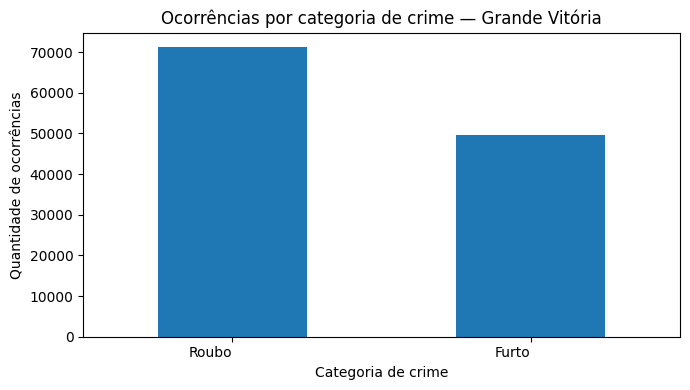

In [16]:

serie_categoria = dados_filtr["CategoriaCrime"].value_counts()
display(serie_categoria.to_frame("ocorrencias"))

grafico_barras(
    serie_categoria,
    "Ocorrências por categoria de crime — Grande Vitória",
    xlabel="Categoria de crime",
    rotacao=0,
    tamanho=(7, 4)
)


### 8.2 Ocorrências por município


,ocorrencias
Municipio,
SERRA,33320
VILA VELHA,28833
VITORIA,26135
CARIACICA,24465
GUARAPARI,4987
VIANA,2229
FUNDAO,727


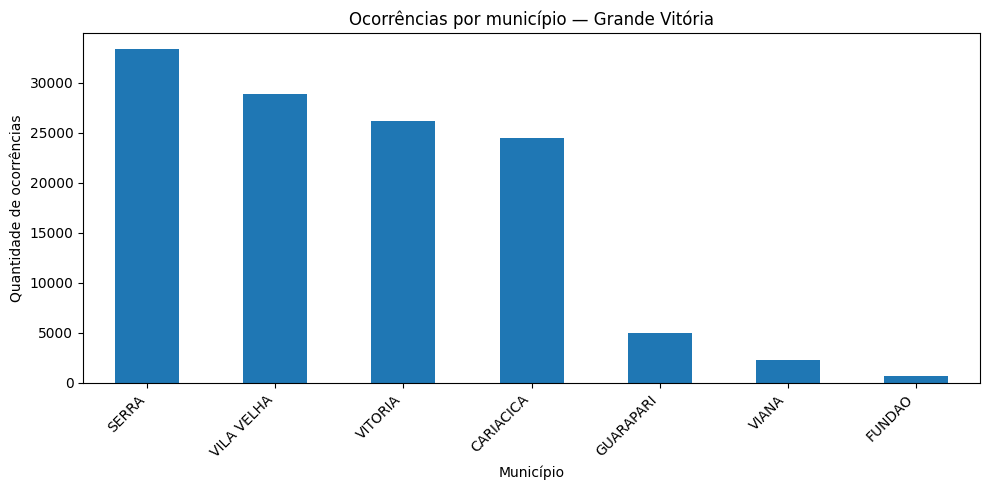

In [17]:

serie_municipio = dados_filtr["Municipio"].value_counts()
display(serie_municipio.to_frame("ocorrencias"))

grafico_barras(
    serie_municipio,
    "Ocorrências por município — Grande Vitória",
    xlabel="Município",
    rotacao=45,
    tamanho=(10, 5)
)


> **Cuidado na interpretação:** este gráfico mostra contagens absolutas. Para comparar risco proporcional entre municípios, será necessário calcular taxas por população, etapa recomendada para a Entrega 3.


### 8.3 Série mensal de ocorrências


,AnoMes,ocorrencias,AnoMesData
0,2021-03,2213,2021-03-01
1,2021-04,1744,2021-04-01
2,2021-05,1904,2021-05-01
3,2021-06,2089,2021-06-01
4,2021-07,2167,2021-07-01


,AnoMes,ocorrencias,AnoMesData
57,2025-12,1194,2025-12-01
58,2026-01,1399,2026-01-01
59,2026-02,1588,2026-02-01
60,2026-03,1423,2026-03-01
61,2026-04,1117,2026-04-01


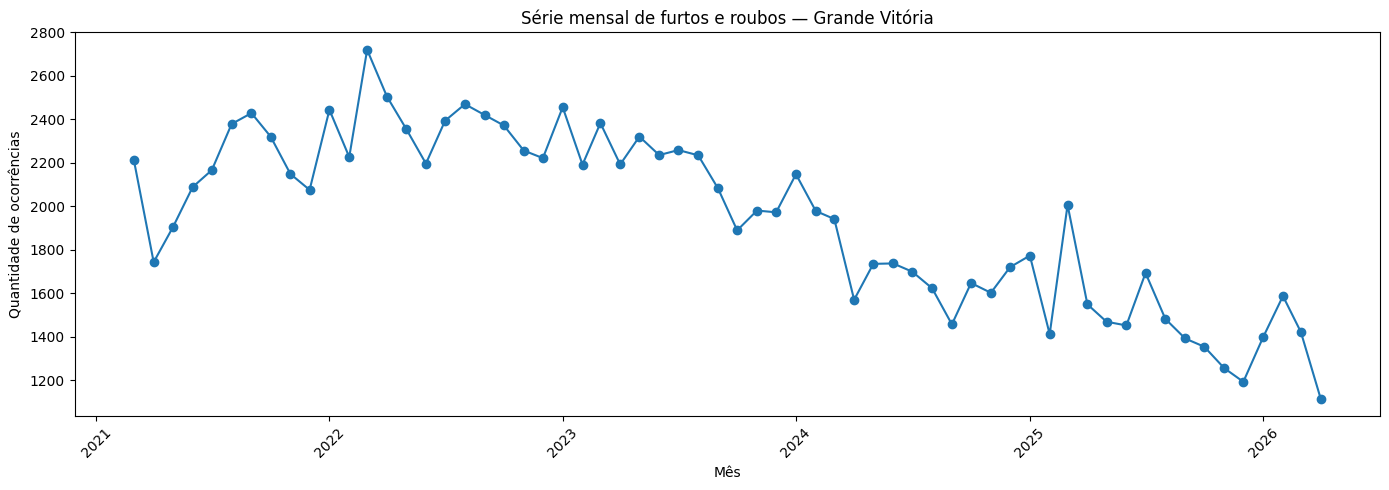

In [18]:

serie_ano_mes = (
    dados_filtr
    .groupby("AnoMes")
    .size()
    .rename("ocorrencias")
    .reset_index()
)
serie_ano_mes["AnoMesData"] = serie_ano_mes["AnoMes"].dt.to_timestamp()

display(serie_ano_mes.head())
display(serie_ano_mes.tail())

plt.figure(figsize=(14, 5))
plt.plot(serie_ano_mes["AnoMesData"], serie_ano_mes["ocorrencias"], marker="o")
plt.title("Série mensal de furtos e roubos — Grande Vitória")
plt.xlabel("Mês")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 8.4 Ocorrências por mês do ano


,ocorrencias
Mes,
1,10221
2,9399
3,12688
4,10680
5,9788
6,9713
7,10214
8,10191
9,9783


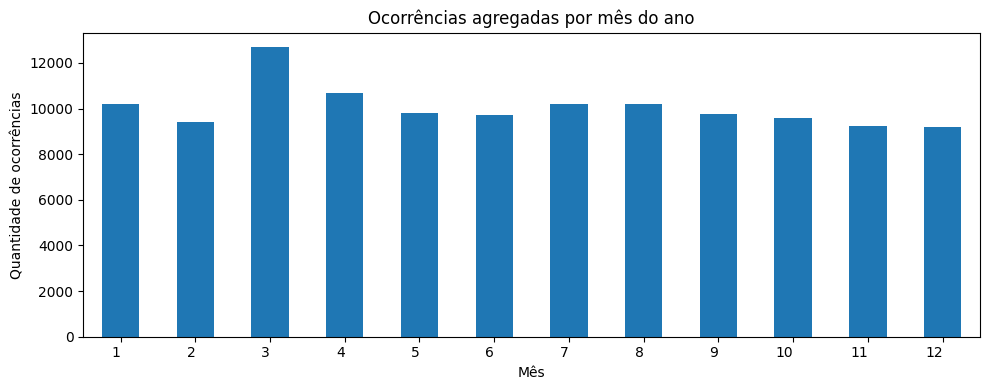

In [19]:

serie_mes = dados_filtr["Mes"].value_counts().sort_index()
display(serie_mes.to_frame("ocorrencias"))

grafico_barras(
    serie_mes,
    "Ocorrências agregadas por mês do ano",
    xlabel="Mês",
    rotacao=0,
    tamanho=(10, 4)
)


### 8.5 Ocorrências por dia da semana


,ocorrencias
DiaSemana,
Segunda-feira,19026
Terça-feira,18341
Quarta-feira,17970
Quinta-feira,17641
Sexta-feira,17466
Sábado,16078
Domingo,14174


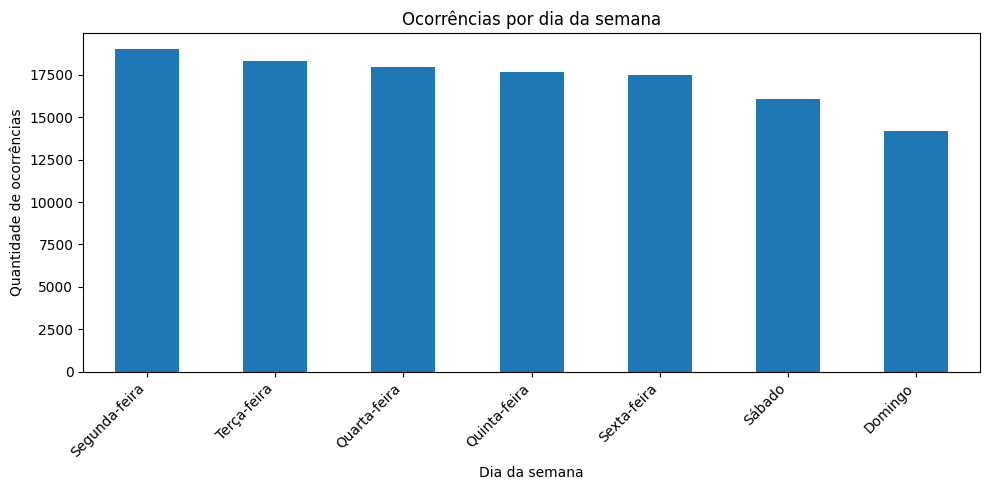

In [20]:

serie_dia = dados_filtr["DiaSemana"].value_counts().reindex(ordem_dias)
display(serie_dia.to_frame("ocorrencias"))

grafico_barras(
    serie_dia,
    "Ocorrências por dia da semana",
    xlabel="Dia da semana",
    rotacao=45,
    tamanho=(10, 5)
)


### 8.6 Ocorrências por hora do dia


,ocorrencias
HoraDia,
0,3704
1,2138
2,2469
3,2475
4,3172
5,5490
6,5143
7,4376
8,3792


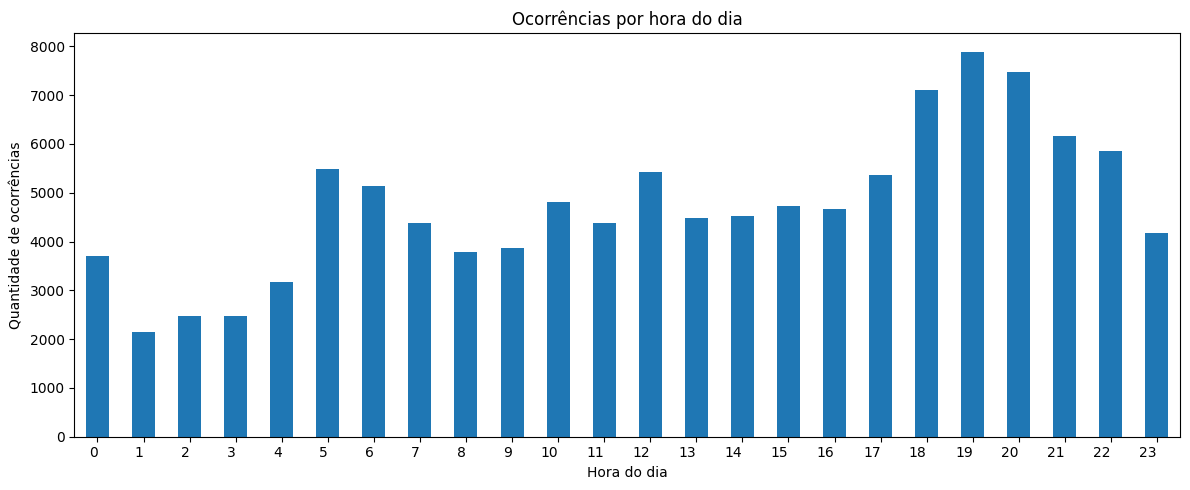

In [21]:

serie_hora = dados_hora["HoraDia"].value_counts().sort_index()
serie_hora = serie_hora.reindex(range(24), fill_value=0)

display(serie_hora.to_frame("ocorrencias"))

grafico_barras(
    serie_hora,
    "Ocorrências por hora do dia",
    xlabel="Hora do dia",
    rotacao=0,
    tamanho=(12, 5)
)


### 8.7 Comparação do padrão horário: furto x roubo


CategoriaCrime,Furto,Roubo
HoraDia,,
0,1860,1844
1,1193,945
2,1663,806
3,1723,752
4,1226,1946
5,891,4599
6,1329,3814
7,1741,2635
8,1771,2021


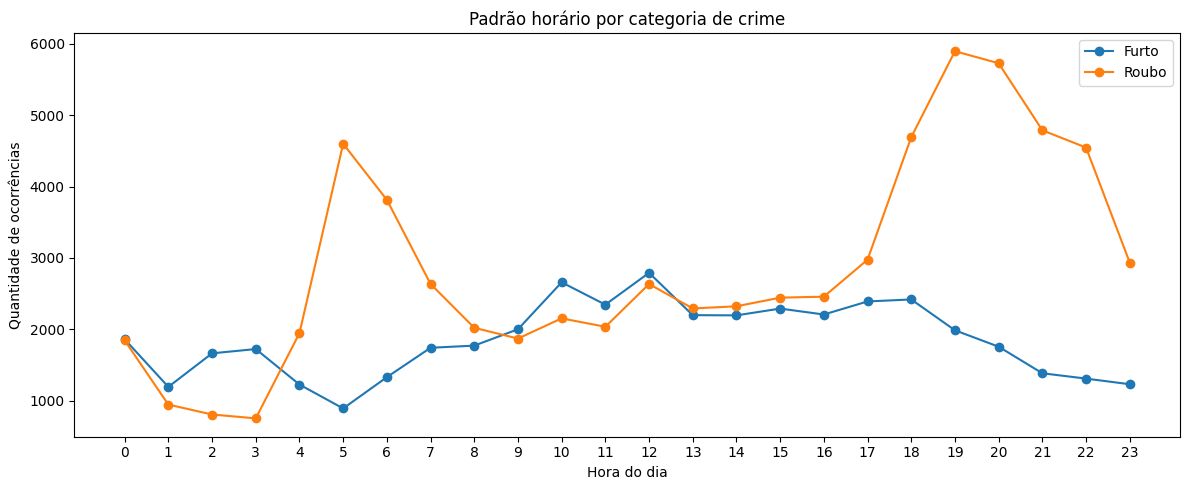

In [22]:

hora_categoria = (
    dados_hora
    .groupby(["HoraDia", "CategoriaCrime"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)

display(hora_categoria)

plt.figure(figsize=(12, 5))
for categoria in hora_categoria.columns:
    plt.plot(hora_categoria.index, hora_categoria[categoria], marker="o", label=categoria)

plt.title("Padrão horário por categoria de crime")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()


### 8.8 Ocorrências por faixa horária


,ocorrencias
FaixaHorario,
Madrugada (00h-05h),19448
Manhã (06h-11h),26372
Tarde (12h-17h),29194
Noite (18h-23h),38667


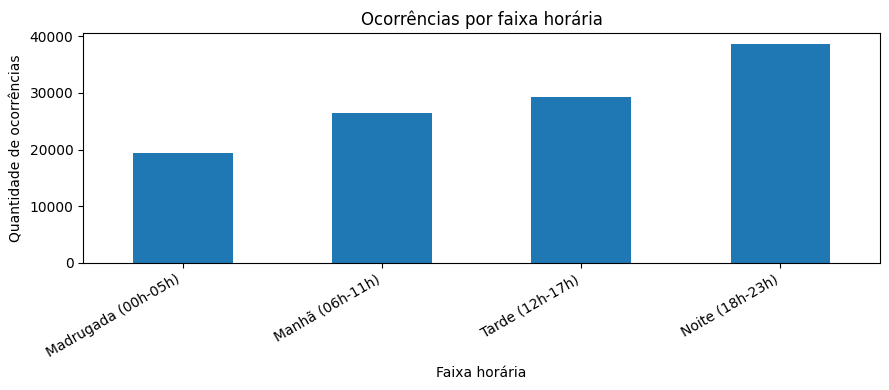

In [23]:

ordem_faixas = [
    "Madrugada (00h-05h)",
    "Manhã (06h-11h)",
    "Tarde (12h-17h)",
    "Noite (18h-23h)",
]

serie_faixa = dados_filtr["FaixaHorario"].value_counts().reindex(ordem_faixas)
display(serie_faixa.to_frame("ocorrencias"))

grafico_barras(
    serie_faixa,
    "Ocorrências por faixa horária",
    xlabel="Faixa horária",
    rotacao=30,
    tamanho=(9, 4)
)


### 8.9 Heatmap hora × dia da semana


HoraDia,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
DiaSemana,,,,,,,,,,,,,,,,,,,,,,,,
Segunda-feira,539,315,360,363,598,942,945,790,657,658,729,676,882,688,662,733,658,850,1188,1239,1160,936,838,507
Terça-feira,485,229,296,320,487,918,842,752,599,622,767,695,882,737,670,713,742,794,1085,1189,1113,902,878,598
Quarta-feira,473,261,285,304,454,906,864,775,570,561,747,696,868,716,703,650,677,738,1079,1242,1115,881,812,565
Quinta-feira,528,258,309,331,413,842,819,697,590,592,746,658,886,695,664,686,639,753,1092,1170,1040,892,813,545
Sexta-feira,558,279,312,321,419,869,769,619,587,553,696,662,803,678,652,699,645,852,1058,1152,1025,787,791,610
Sábado,574,411,479,438,444,577,498,414,441,487,649,602,661,562,626,624,658,689,840,974,1004,855,902,702
Domingo,547,385,428,398,357,436,406,329,348,397,477,391,443,414,540,628,645,689,768,916,1026,919,821,638


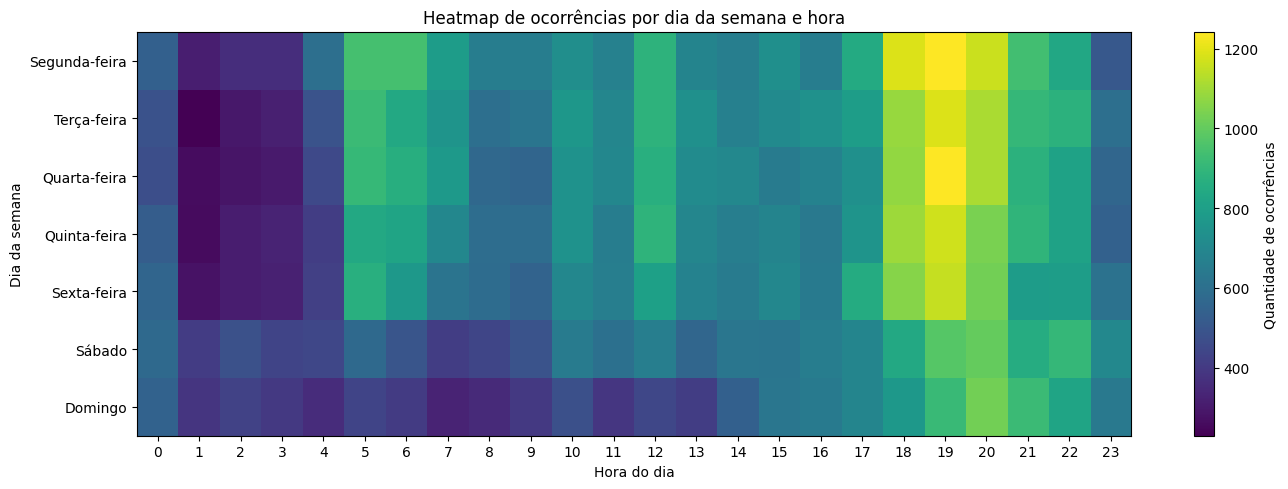

In [24]:

heatmap_hora_dia = (
    dados_hora
    .groupby(["DiaSemana", "HoraDia"])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_dias)
    .reindex(columns=range(24), fill_value=0)
)

display(heatmap_hora_dia)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_hora_dia, aspect="auto")
plt.title("Heatmap de ocorrências por dia da semana e hora")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.xticks(ticks=range(24), labels=range(24))
plt.yticks(ticks=range(len(ordem_dias)), labels=ordem_dias)
plt.colorbar(label="Quantidade de ocorrências")
plt.tight_layout()
plt.show()


## 9. Baseline/modelo inicial

Nesta Entrega 2, o objetivo do baseline não é criar o melhor modelo, mas sim estabelecer uma referência mínima para a próxima etapa.

A estratégia usada aqui é prever a quantidade de ocorrências de um mês usando informações simples do histórico:

1. **Baseline ingênuo:** previsão do mês atual = quantidade do mês anterior;
2. **Baseline de média móvel de 3 meses:** previsão do mês atual = média dos 3 meses anteriores.

Na Entrega 3, modelos mais sofisticados devem ser comparados com esses resultados.


In [25]:

serie_modelo = (
    dados_filtr
    .groupby("AnoMes")
    .size()
    .rename("Ocorrencias")
    .reset_index()
    .sort_values("AnoMes")
)

serie_modelo["AnoMesData"] = serie_modelo["AnoMes"].dt.to_timestamp()
serie_modelo["Baseline_Ingenuo"] = serie_modelo["Ocorrencias"].shift(1)
serie_modelo["Baseline_MM3"] = serie_modelo["Ocorrencias"].shift(1).rolling(window=3).mean()

# Avaliação simples usando os últimos 6 meses disponíveis.
meses_teste = 6
avaliacao = serie_modelo.dropna(subset=["Baseline_Ingenuo", "Baseline_MM3"]).copy()
teste = avaliacao.tail(meses_teste).copy()

def calcular_metricas(y_real, y_previsto):
    erro = y_real - y_previsto
    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro ** 2))
    return mae, rmse

resultados = []
for modelo in ["Baseline_Ingenuo", "Baseline_MM3"]:
    mae, rmse = calcular_metricas(teste["Ocorrencias"], teste[modelo])
    resultados.append({
        "modelo": modelo,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    })

resultados_baseline = pd.DataFrame(resultados)

display(teste[["AnoMes", "Ocorrencias", "Baseline_Ingenuo", "Baseline_MM3"]])
display(resultados_baseline)


,AnoMes,Ocorrencias,Baseline_Ingenuo,Baseline_MM3
56,2025-11,1257,1355.0,1410.333333
57,2025-12,1194,1257.0,1335.000000
58,2026-01,1399,1194.0,1268.666667
59,2026-02,1588,1399.0,1283.333333
60,2026-03,1423,1588.0,1393.666667
61,2026-04,1117,1423.0,1470.000000


,modelo,MAE,RMSE
0,Baseline_Ingenuo,171.00,188.05
1,Baseline_MM3,185.28,215.51


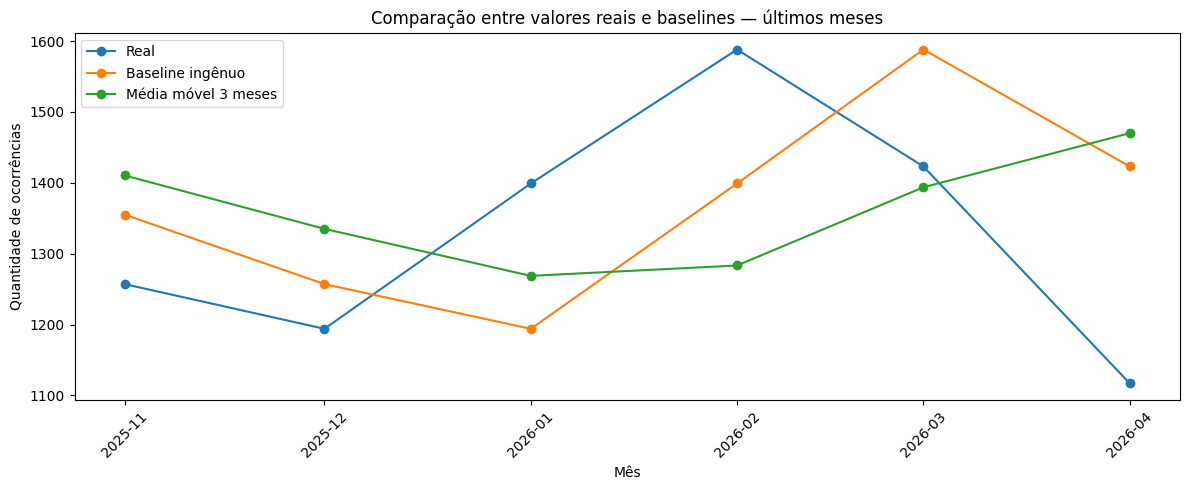

In [26]:

plt.figure(figsize=(12, 5))
plt.plot(teste["AnoMesData"], teste["Ocorrencias"], marker="o", label="Real")
plt.plot(teste["AnoMesData"], teste["Baseline_Ingenuo"], marker="o", label="Baseline ingênuo")
plt.plot(teste["AnoMesData"], teste["Baseline_MM3"], marker="o", label="Média móvel 3 meses")
plt.title("Comparação entre valores reais e baselines — últimos meses")
plt.xlabel("Mês")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Interpretação do baseline

O baseline serve como referência inicial. Se modelos futuros, como regressão, árvores de decisão ou modelos de séries temporais, não conseguirem superar esse resultado, eles não estarão trazendo ganho prático suficiente.

Para a Entrega 2, basta mostrar que o grupo já tem uma primeira forma de previsão e uma métrica objetiva de comparação, como MAE e RMSE.


## 10. Principais insights preliminares


In [27]:

# Célula auxiliar para gerar números que podem ser usados na seção de insights.
maior_municipio = serie_municipio.idxmax()
qtd_maior_municipio = serie_municipio.max()

maior_hora = serie_hora.idxmax()
qtd_maior_hora = serie_hora.max()

maior_dia = serie_dia.idxmax()
qtd_maior_dia = serie_dia.max()

categoria_mais_freq = serie_categoria.idxmax()
qtd_categoria_mais_freq = serie_categoria.max()

print("Resumo para escrita dos insights:")
print(f"Total no recorte: {len(dados_filtr):,}".replace(",", "."))
print(f"Categoria mais frequente: {categoria_mais_freq} ({qtd_categoria_mais_freq:,} registros)".replace(",", "."))
print(f"Município com maior contagem absoluta: {maior_municipio} ({qtd_maior_municipio:,} registros)".replace(",", "."))
print(f"Dia da semana com maior contagem: {maior_dia} ({qtd_maior_dia:,} registros)".replace(",", "."))
print(f"Hora com maior contagem geral: {maior_hora}h ({qtd_maior_hora:,} registros)".replace(",", "."))


Resumo para escrita dos insights:
Total no recorte: 120.696
Categoria mais frequente: Roubo (71.181 registros)
Município com maior contagem absoluta: SERRA (33.320 registros)
Dia da semana com maior contagem: Segunda-feira (19.026 registros)
Hora com maior contagem geral: 19h (7.882 registros)


Escreva os insights finais depois de rodar todas as células. Uma versão inicial possível é:

1. Após aplicar o recorte de período, municípios da Grande Vitória e tipos de crime relacionados a furto e roubo, a base permaneceu com volume suficiente para análise exploratória.
2. As ocorrências não se distribuem igualmente entre os municípios. Porém, nesta etapa, a comparação ainda é feita por contagem absoluta, sem ajuste populacional.
3. A análise horária indica concentração de ocorrências no fim da tarde e no período noturno, o que reforça o foco temporal definido pelo projeto.
4. Ao separar furto e roubo, é possível observar padrões horários diferentes entre as categorias, sugerindo que os crimes não possuem a mesma dinâmica temporal.
5. Registros com horário indeterminado foram excluídos apenas das análises por hora, mantendo transparência sobre a limitação dos dados.
6. O baseline mensal cria uma referência inicial para que modelos mais robustos sejam avaliados na Entrega 3.

> Antes de gravar o vídeo, substitua esta seção por frases com os números exatos gerados pelas células acima.


## 11. Próximos passos para a Entrega 3


Para a próxima entrega, o grupo pode evoluir o projeto com:

1. **Taxas por população:** comparar municípios por taxa por 100 mil habitantes, não apenas por contagem absoluta.
2. **Modelos mais robustos:** testar regressão, modelos de séries temporais ou modelos supervisionados com variáveis temporais.
3. **Validação temporal:** separar treino e teste respeitando a ordem dos meses, evitando vazamento de dados futuros.
4. **Análise por município:** avaliar se cada município possui padrão horário próprio.
5. **Análise espacial:** incorporar mapas ou análises por bairro, caso os dados permitam.
6. **Documentação no GitHub:** manter notebook, base tratada, README e vídeo organizados no repositório.


## 12. Salvamento opcional da base tratada


In [28]:

# Esta célula é opcional.
# Use apenas se o grupo quiser salvar a base já filtrada e tratada para reaproveitar na Entrega 3.

# caminho_saida = Path("../dados/tratados/ocorrencias_gv_furtos_roubos_tratada.csv")
# caminho_saida.parent.mkdir(parents=True, exist_ok=True)
# dados_filtr.to_csv(caminho_saida, index=False, sep=";", encoding="utf-8")
# print(f"Base tratada salva em: {caminho_saida}")


## 13. Observações sobre preservação do rascunho original

Este notebook foi reorganizado sem modificar o arquivo original. As partes importantes do rascunho foram incorporadas em uma sequência mais segura:

- introdução do tema;
- carregamento da base;
- conferência de colunas, tamanho, tipos e valores ausentes;
- padronização textual;
- tratamento de data;
- filtros de período, município e tipo de crime;
- criação de variáveis temporais;
- testes de contagem por município e tipo de incidente;
- gráficos exploratórios;
- baseline inicial.

Também foi corrigido o principal problema identificado no rascunho: o filtro dos municípios precisava usar a coluna `Municipio`, e não `TipoIncidente`.
